# Cardiovascular Disease Prediction

**Objective:** Build a logistic regression model to predict whether patients have 10 year risk of coronary heart disease (CHD) and create visualizations to gain actionable insight.

**Pipeline:**

**1. Data Understanding and Preparation**
- 1.1 Data loading and inspection
- 1.2 Missingness analysis
- 1.3 Data cleaning strategy

**2. Exploratory Data Analysis**
- 2.1 Target variable — class balance
- 2.2 Numeric feature distributions
- 2.3 Categorical feature distributions
- 2.4 Numeric correlations and box comparisons
- 2.5 Variable selection

**3. Modeling**
- 3.1 Model preparation
- 3.2 Logistic regression
- 3.3 Metric selection and threshold optimization
- 3.4 Model accuracy metrics
- 3.5 Coefficient interpretation and predictive power

**4. Key Findings and Conclusions**



In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score

%matplotlib inline

# 1. Data Understanding and Preparation

## 1.1 Data Loading and Inspection

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
cardio_data = pd.read_csv('/content/drive/MyDrive/train.csv')
print(f'Shape: {cardio_data.shape}')
cardio_data.head()

Shape: (3390, 17)


,id,age,education,sex,is_smoking,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,0,64,2.0,F,YES,3.0,0.0,0,0,0,221.0,148.0,85.0,NaN,90.0,80.0,1
1,1,36,4.0,M,NO,0.0,0.0,0,1,0,212.0,168.0,98.0,29.77,72.0,75.0,0
2,2,46,1.0,F,YES,10.0,0.0,0,0,0,250.0,116.0,71.0,20.35,88.0,94.0,0
3,3,50,1.0,M,YES,20.0,0.0,0,1,0,233.0,158.0,88.0,28.26,68.0,94.0,1
4,4,64,1.0,F,YES,30.0,0.0,0,0,0,241.0,136.5,85.0,26.42,70.0,77.0,0


In [5]:
cardio_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3390 entries, 0 to 3389
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               3390 non-null   int64  
 1   age              3390 non-null   int64  
 2   education        3303 non-null   float64
 3   sex              3390 non-null   object 
 4   is_smoking       3390 non-null   object 
 5   cigsPerDay       3368 non-null   float64
 6   BPMeds           3346 non-null   float64
 7   prevalentStroke  3390 non-null   int64  
 8   prevalentHyp     3390 non-null   int64  
 9   diabetes         3390 non-null   int64  
 10  totChol          3352 non-null   float64
 11  sysBP            3390 non-null   float64
 12  diaBP            3390 non-null   float64
 13  BMI              3376 non-null   float64
 14  heartRate        3389 non-null   float64
 15  glucose          3086 non-null   float64
 16  TenYearCHD       3390 non-null   int64  
dtypes: float64(9),

## 1.2 Missingness Analysis
Before cleaning, we need to understand the structure of missing data — how much is missing, which columns are affected, and whether the missingness is random or systematic.

In [6]:
total_missing = cardio_data.isnull().sum().sum()
total_values = cardio_data.size

percent_missing = (total_missing/total_values) * 100
print(f'Overall percent missing: {percent_missing:.2f}%')

percent_missing_col = (cardio_data.isnull().sum()/len(cardio_data)) * 100
print('\nMissing % per column:')
print(percent_missing_col[percent_missing_col > 0].sort_values(ascending=False).round(2))

Overall percent missing: 0.88%

Missing % per column:
glucose       8.97
education     2.57
BPMeds        1.30
totChol       1.12
cigsPerDay    0.65
BMI           0.41
heartRate     0.03
dtype: float64


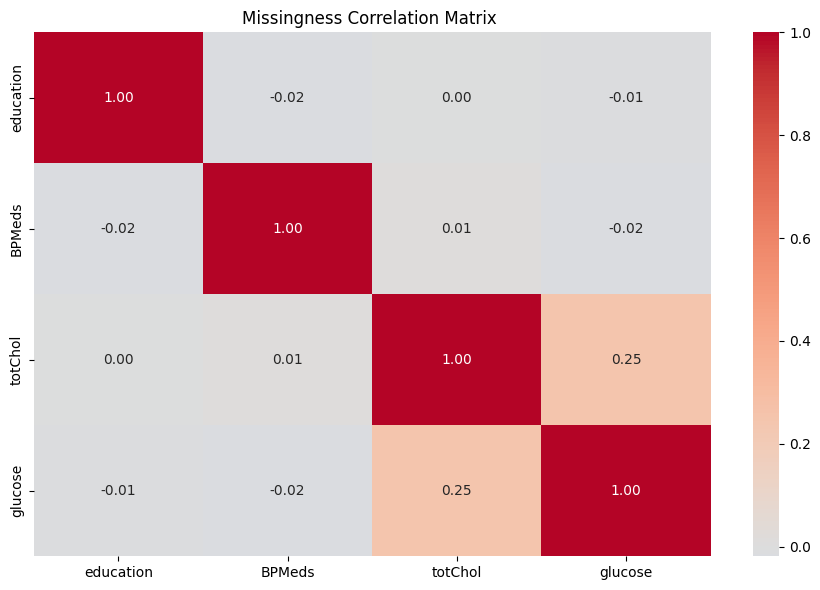

In [7]:
miss = cardio_data.isnull().astype(float)
float_cols = cardio_data.select_dtypes(include=['float64']).columns
float_missing_pct = (miss[float_cols].sum()/len(cardio_data)) * 100

high_miss_cols = float_missing_pct[float_missing_pct > 1]

high_miss_data = miss[high_miss_cols.index]
corr = high_miss_data.corr()
plt.figure(figsize=(9, 6))
sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0,
    annot=True,
    fmt='.2f'
)
plt.title('Missingness Correlation Matrix ')
plt.tight_layout()
plt.show()

**The heatmap reveals only one weak correlation of missingness:**
* **The pairing of totChol (total cholesterol) and glucose** shows a weak but real correlation, indicating that they may have a common mechanism for missigness (i.e. patients did not receive lab tests during visits).
* **These data appear to be MAR** and may introduce bias if not handled correctly

Other missingness has no correlation with other factors
* These data appear to be MCAR

**Imputation Strategy**

* **Median Imputation** - with missingness at low levels throughout, even with the ~9% glucose levels, median imputation seems like an appropriate way to handle missing data


##1.3 Data Cleaning Strategy (EDA-only copy)

In [8]:
# Build a cleaned copy for EDA/visualization purposes only.
# This does NOT feed the model — cardio_data stays raw and untouched
# so Section 3 can build its own train-only preprocessing pipeline from it.

cardio_cleaned = cardio_data.copy()

for col in ['glucose', 'education', 'BPMeds', 'totChol', 'cigsPerDay', 'BMI', 'heartRate']:
    cardio_cleaned[col] = cardio_cleaned[col].fillna(cardio_cleaned[col].median())

print(cardio_cleaned[['glucose', 'education', 'BPMeds', 'totChol',
                       'cigsPerDay', 'BMI', 'heartRate']].isnull().sum())

glucose       0
education     0
BPMeds        0
totChol       0
cigsPerDay    0
BMI           0
heartRate     0
dtype: int64


# 2. Exploratory Data Analysis

## 2.1 Target Variable: Class Distribution for TenYear CHD

TenYearCHD
0    2879
1     511
Name: count, dtype: int64
TenYearCHD
0    0.849
1    0.151
Name: proportion, dtype: float64


Text(0, 0.5, 'Proportion')

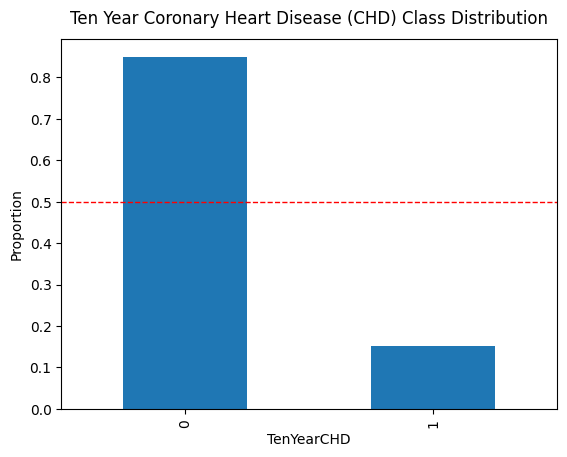

In [9]:
# check class distribution
print(cardio_cleaned['TenYearCHD'].value_counts())
print(cardio_cleaned['TenYearCHD'].value_counts(normalize=True).round(3))

cardio_cleaned['TenYearCHD'].value_counts(normalize=True).plot(kind='bar')
plt.axhline(y=0.5, color='red', linestyle='--', linewidth=1)
plt.title('Ten Year Coronary Heart Disease (CHD) Class Distribution', y= 1.02)
plt.ylabel('Proportion')

**Class Imbalance:**
* There is a large class imbalance in the data sample between those who do no and those who do come to have TenYear coronary heart disease (CHD)
* This influences many downstream decisions such as what type of metric should be the focus in a regression model


## 2.2 Examining Potential Features (Numeric)

In [10]:
# grab and filter numeric columns
numeric_cols = cardio_cleaned.select_dtypes(include=['float64','int64']).columns.tolist()
print(numeric_cols)

['id', 'age', 'education', 'cigsPerDay', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD']


In [11]:
exclude = ['id', 'TenYearCHD', 'prevalentStroke', 'prevalentHyp', 'diabetes','education', 'BPMeds']
numeric_cols = [col for col in numeric_cols if col not in exclude]
print(numeric_cols)

['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']


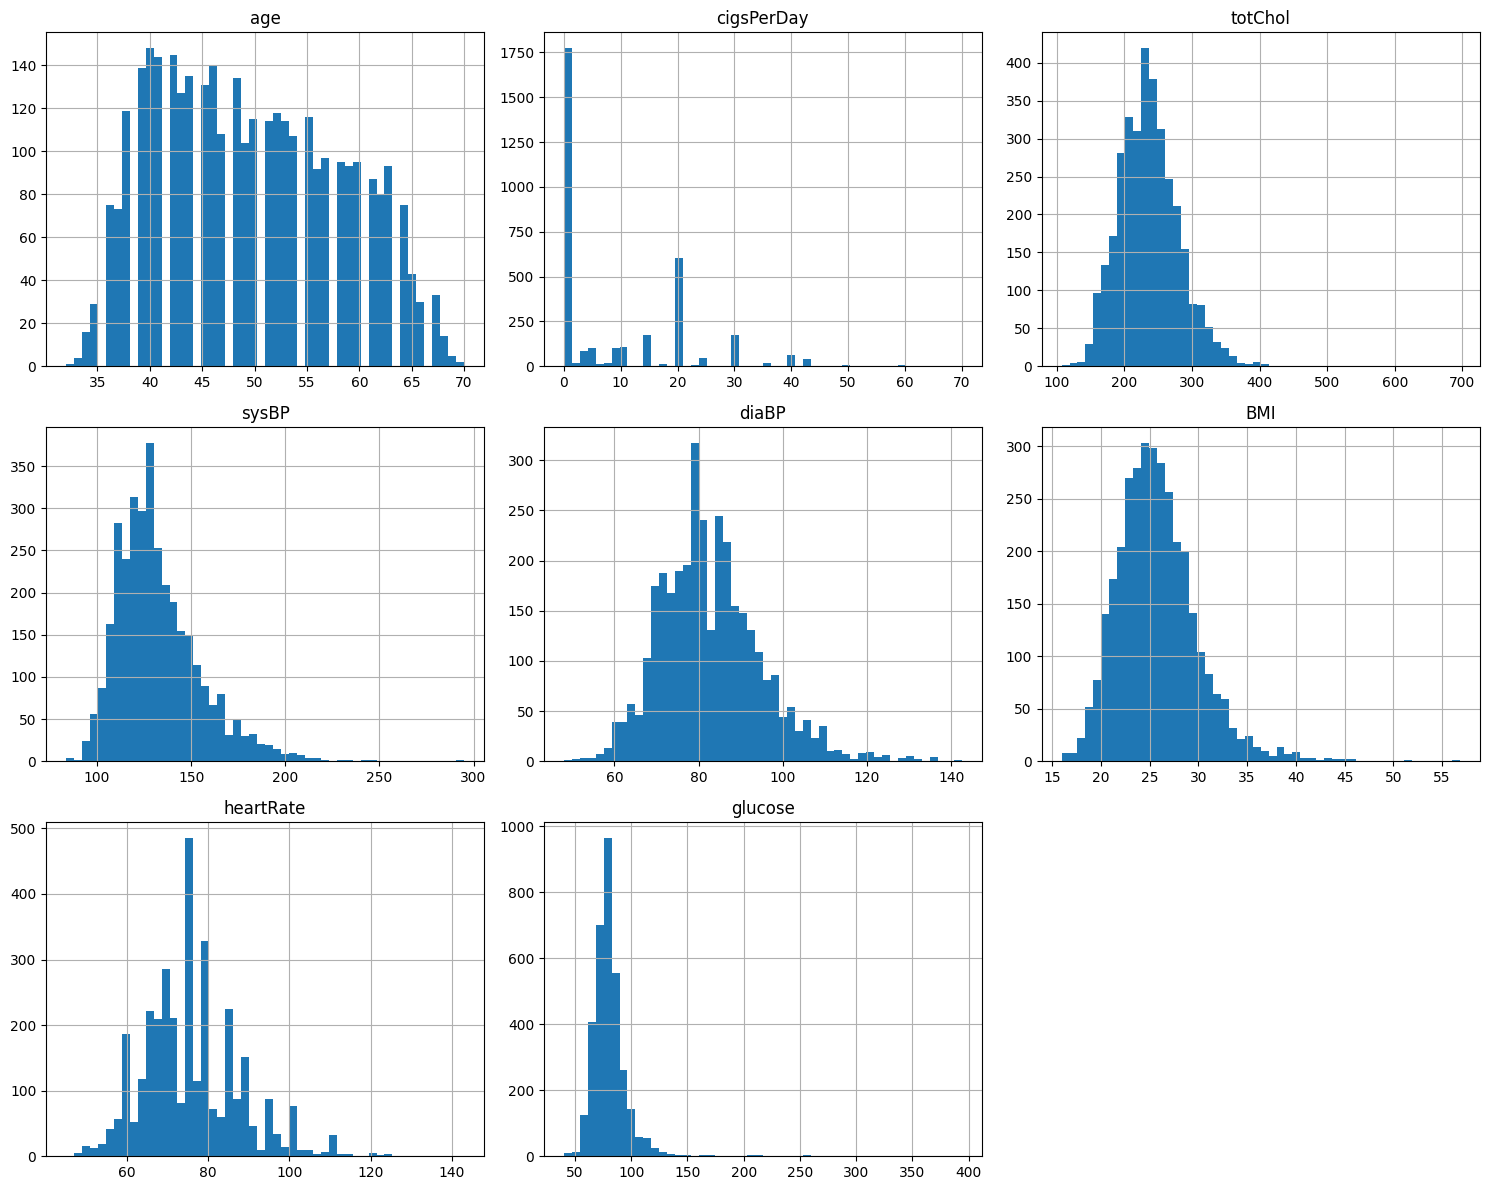

In [12]:
# Create sublots of numeric columns as initial observation
cardio_cleaned[numeric_cols].hist(bins=50, figsize=(15, 12))
plt.tight_layout()
plt.show()

In [13]:
# closer look at diaBP range to inform decision about winsorizing
print(cardio_cleaned['diaBP'].describe())

count    3390.000000
mean       82.883038
std        12.023581
min        48.000000
25%        74.500000
50%        82.000000
75%        90.000000
max       142.500000
Name: diaBP, dtype: float64


Key Observations:
* Age has a roughly normal distribution. The range is 32-70, a middle-aged adult which confirms the clinically relevant population
* **Action** - outliers for **totChol** and **glucose** should be winsorized. Not transformed due to range being not the most extreme and because logistic regression's relative robustness to skew
* **Action** - **cigsPerDay** can be changed to a categorical feature to better show large group of non-smokers versus smokers
* **Action** - looks more closely at **heartRate(with larger bins)** to investigate jagged pattern
* **Action** - **sysBP** is slightly right skewed and outliers can be winsorized
* diaBP is slightly right skewed but not outlier treatment needed
* BMI has a slight right skew but outliers do not need to be treated

### 2.2.1 Converting Smoker to Binary Categorical

In [14]:
# convert smoker column to binary categorical
cardio_cleaned['is_smoker'] = (cardio_cleaned['cigsPerDay'] > 0).astype(int)
print(cardio_cleaned['is_smoker'].dtype)
print(cardio_cleaned['is_smoker'].unique())
print(cardio_cleaned['is_smoker'].value_counts())

int64
[1 0]
is_smoker
0    1725
1    1665
Name: count, dtype: int64


**The binary 'is_smoker' feature distribution** shows 1,725 non-smokers (50.9%), 1,665 smokers (49.1%).
* It is nearly balanced as opposed to the zero-inflated continuous distribution of 'cigsPerDay'.
* The binary smoking/non-smoking split will have **more discriminating power** as a balanced feature.

### 2.2.2 heartRate Distribution

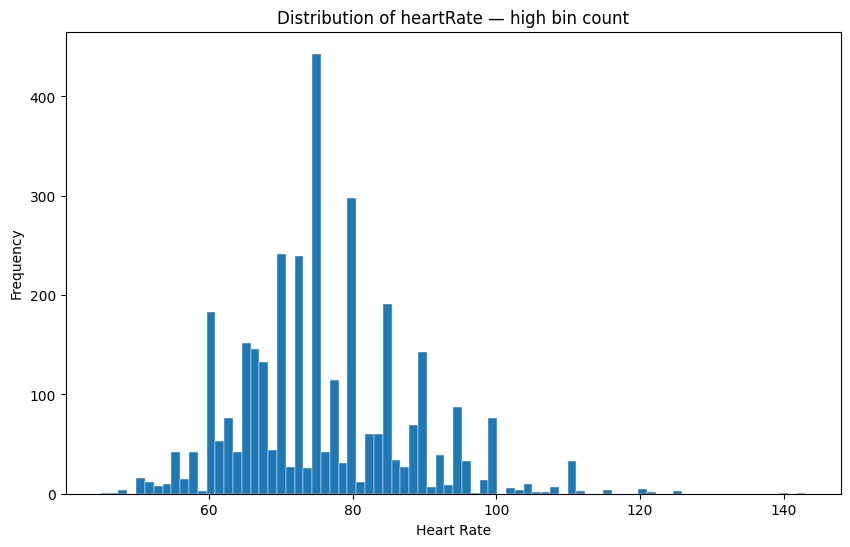

In [15]:
plt.figure(figsize =(10, 6))
plt.hist(cardio_cleaned['heartRate'].dropna(), bins = 80, edgecolor = 'white', linewidth = 0.3)
plt.title('Distribution of heartRate — high bin count')
plt.xlabel('Heart Rate')
plt.ylabel('Frequency')
plt.show()

**HeartRate Observation:**

Distribution is approximately normal (center ~75 bpm, range ~45–140) but tall spikes at even values shows discrete recording intervals rather than continuous measures. This confirms manual clinical rounding during data collection. This is a measurement artifact, not a biological pattern.

There is no transformation or outlier treatment required. The tail above 110 represents a small number of genuine tachycardic patients.

> **Note:** heartRate discretization should be acknowledged when interpreting model coefficients — a one-unit increase in heartRate does not reflect a truly continuous measurement

### 2.2.3 Treating Outlers (totChol, glucose, and sysBP)

In [16]:
# -- resuable winsorizing functions ----------------
def winsorize_iqr(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[col].clip(lower, upper)

def winsorize_zscore(df, col, threshold= 3):
    mean = df[col].mean()
    std = df[col].std()
    lower = mean - threshold * std
    upper = mean + threshold * std
    return df[col].clip(lower, upper)

# -- Apply IQR to skewed variables ----------

iqr_cols = ['totChol', 'glucose']

for col in iqr_cols:
    before = cardio_cleaned[col].describe()
    cardio_cleaned[col] = winsorize_iqr(cardio_cleaned, col)
    after = cardio_cleaned[col].describe()
    print(f'{col}:max before={before["max"]:.1f}, max after={after["max"]:.1f}')


zscore_col = ['sysBP']

for col in zscore_col:
    before = cardio_cleaned[col].describe()
    cardio_cleaned[col] = winsorize_zscore(cardio_cleaned, col)
    after = cardio_cleaned[col].describe()
    print(f'{col}:max before={before["max"]:.1f}, max after={after["max"]:.1f}')

# -- Validate --------------
print('\nDataset shape after winsorizing:')
print(cardio_cleaned.shape)

winsorized_cols = iqr_cols + zscore_col
cardio_cleaned[winsorized_cols].describe().round(2)

totChol:max before=696.0, max after=351.0
glucose:max before=394.0, max after=104.5
sysBP:max before=295.0, max after=199.5

Dataset shape after winsorizing:
(3390, 18)


,totChol,glucose,sysBP
count,3390.00,3390.00,3390.00
mean,236.54,79.49,132.42
std,42.84,11.53,21.59
min,119.00,52.50,83.50
25%,206.00,72.00,117.00
50%,234.00,78.00,128.50
75%,264.00,85.00,144.00
max,351.00,104.50,199.48


**Outlier Treatment Results**

| Variable | Method | Max Before | Max After | Change |
|----------|--------|-----------|-----------|--------|
| totChol | IQR | 696.0 | 351.0 | Capped — extreme values compressed |
| glucose | IQR | 394.0 | 104.5 | Capped — extreme values compressed |
| sysBP | Z-score | 295.5 | 199.5 | Capped — extreme hypertensive values |

**Observations:**
* All three variables had meaningful outlier values capped. totChol
and glucose showed the most dramatic reduction — values nearly
double the IQR boundary were present before treatment. sysBP
had a smaller but real reduction at the upper tail.
> **Note:** glucose values may be compressed due to previous median imputation, since diabetic readings typically exceed 126

## 2.3 Examining Potential Features (Categorical)

**Visualization 1 — counts with CHD split**
How many patients in each binary feature category developed CHD versus did not? *Sample size matters here.* Elevated CHD rates in small groups are less reliable than the same rates in larger groups.
* *Orientation:* 0 = absence of the condition or behavior (e.g. not on BP meds, no prior stroke, non-smoker);  1 = presence of the condition or behavior
* *Example question:* how many people who did and did not take BPMeds developed CHD over 10 years?

**Visualization 2 — CHD rate by category**
What proportion of patients in each category developed CHD, and how does that compare to the overall population rate of 15.1%?

* *Example question:* does the proportion of BPMeds patients who developed CHD differ meaningfully from non-BPMeds patients — and
from the overall 15.1% baseline?

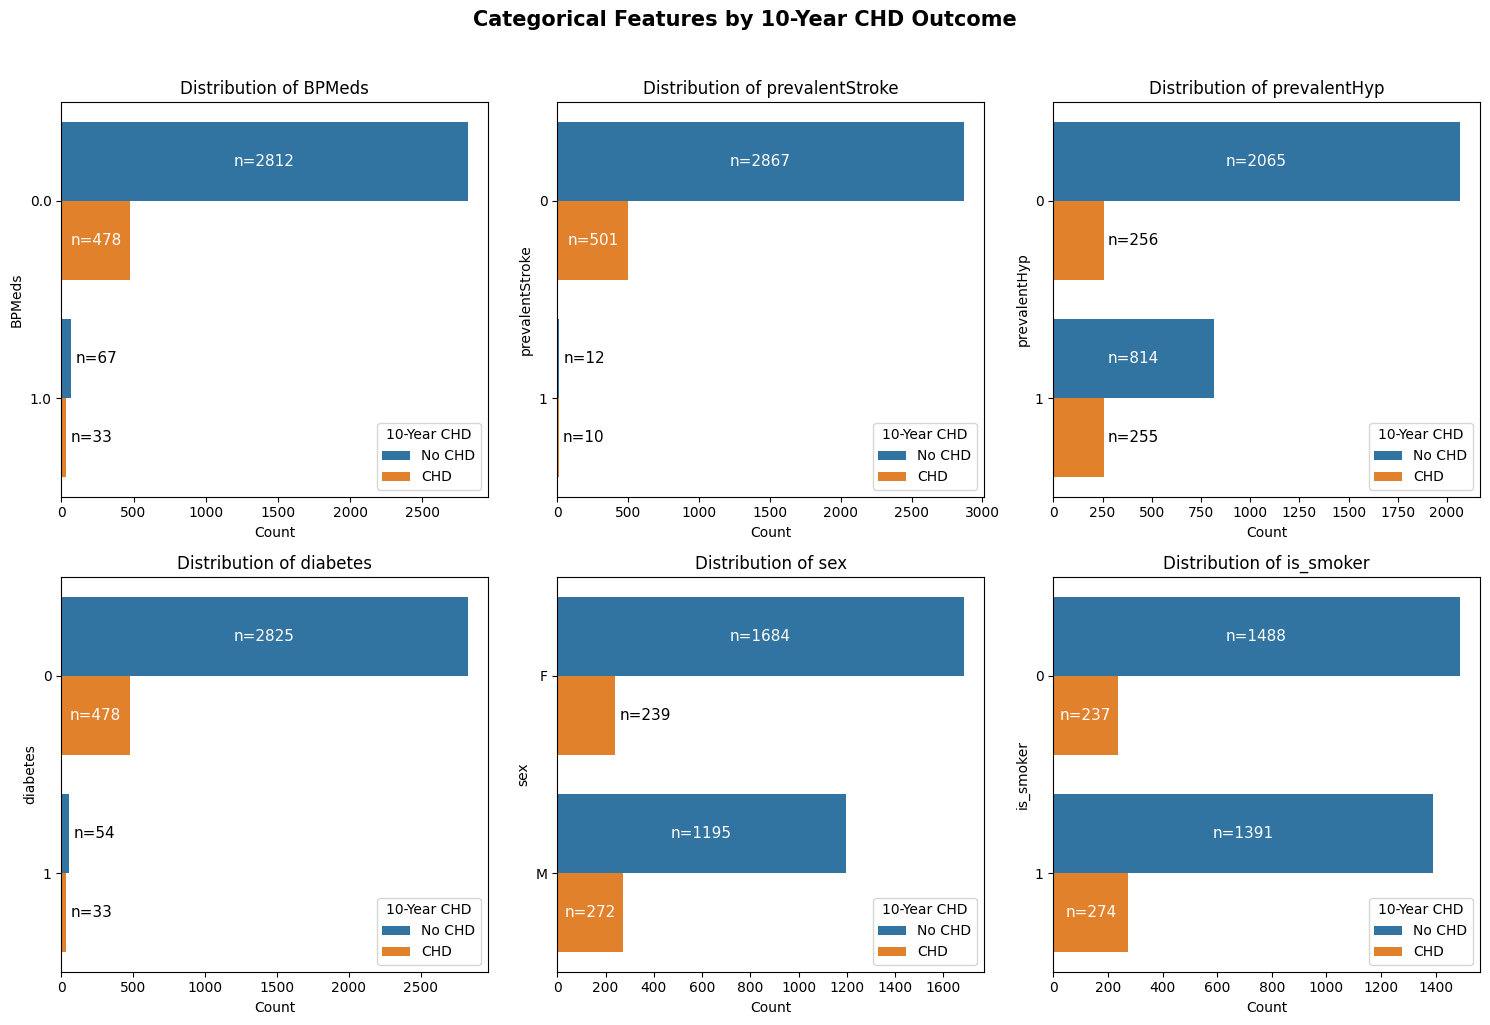

--- BPMeds ---
  Group 0.0: CHD rate = 0.145 | n = 3290
  Group 1.0: CHD rate = 0.330 | n = 100
Group 1.0 has a 2.3x higher CHD rate than group 0.0
Absolute difference: 18.5%

--- prevalentStroke ---
  Group 0: CHD rate = 0.149 | n = 3368
  Group 1: CHD rate = 0.455 | n = 22
Group 1 has a 3.1x higher CHD rate than group 0
Absolute difference: 30.6%

--- prevalentHyp ---
  Group 0: CHD rate = 0.110 | n = 2321
  Group 1: CHD rate = 0.239 | n = 1069
Group 1 has a 2.2x higher CHD rate than group 0
Absolute difference: 12.8%

--- diabetes ---
  Group 0: CHD rate = 0.145 | n = 3303
  Group 1: CHD rate = 0.379 | n = 87
Group 1 has a 2.6x higher CHD rate than group 0
Absolute difference: 23.5%

--- sex ---
  Group F: CHD rate = 0.124 | n = 1923
  Group M: CHD rate = 0.185 | n = 1467
Group M has a 1.5x higher CHD rate than group F
Absolute difference: 6.1%

--- is_smoker ---
  Group 0: CHD rate = 0.137 | n = 1725
  Group 1: CHD rate = 0.165 | n = 1665
Group 1 has a 1.2x higher CHD rate than gro

In [17]:
cat_cols = cardio_cleaned[['BPMeds','prevalentStroke','prevalentHyp',
                                     'diabetes', 'sex', 'is_smoker']]
fig, axes = plt.subplots(2,3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ax = axes[i]
    sns.countplot(
        data=cardio_cleaned,
        y=col,
        ax=ax,
        hue='TenYearCHD',
        order=cardio_cleaned[col].value_counts().index
    )
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel('Count')
    ax.set_ylabel(col)

    total = len(cardio_cleaned)
    for patch in ax.patches:
        width = patch.get_width()
        if width > 0:
            x_limit = ax.get_xlim()[1]  # the max x value on this subplot

            # if bar is wide enough, place label inside; otherwise outside
            if width > x_limit * 0.15:
                x_pos = width / 2        # center of bar
                color = 'white'
                ha = 'center'
            else:
                x_pos = width + x_limit * 0.01  # just outside bar end
                color = 'black'
                ha = 'left'

            ax.text(
                x_pos,
                patch.get_y() + patch.get_height() / 2,
                f'n={int(width)}',
                va='center',
                ha=ha,
                color=color,
                fontsize=11
            )

    # replace legend labels with meaningful text
    legend = ax.get_legend()
    if legend:
        legend.set_title('10-Year CHD')
        for text, label in zip(legend.get_texts(), ['No CHD', 'CHD']):
            text.set_text(label)

fig.suptitle('Categorical Features by 10-Year CHD Outcome', fontsize= 15, weight='bold', y=1.02)
fig.tight_layout()
plt.show()

# print chd rates and relative and absolute changes
cat_cols_list = ['BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'sex', 'is_smoker']

for col in cat_cols_list:
    chd_rate = cardio_cleaned.groupby(col)['TenYearCHD'].mean()
    counts = cardio_cleaned.groupby(col)['TenYearCHD'].count()
    groups = chd_rate.index.tolist()

    print(f'--- {col} ---')

    for g in groups:
        print(f'  Group {g}: CHD rate = {chd_rate[g]:.3f} | n = {counts[g]}')

    if len(groups) == 2:
        g0, g1 = groups[0], groups[1]
        relative_change = chd_rate[g1] / chd_rate[g0]
        abs_change = chd_rate[g1] - chd_rate[g0]
        print(f'Group {g1} has a {relative_change:.1f}x higher CHD rate than group {g0}')
        print(f'Absolute difference: {abs_change:.1%}')
    print()

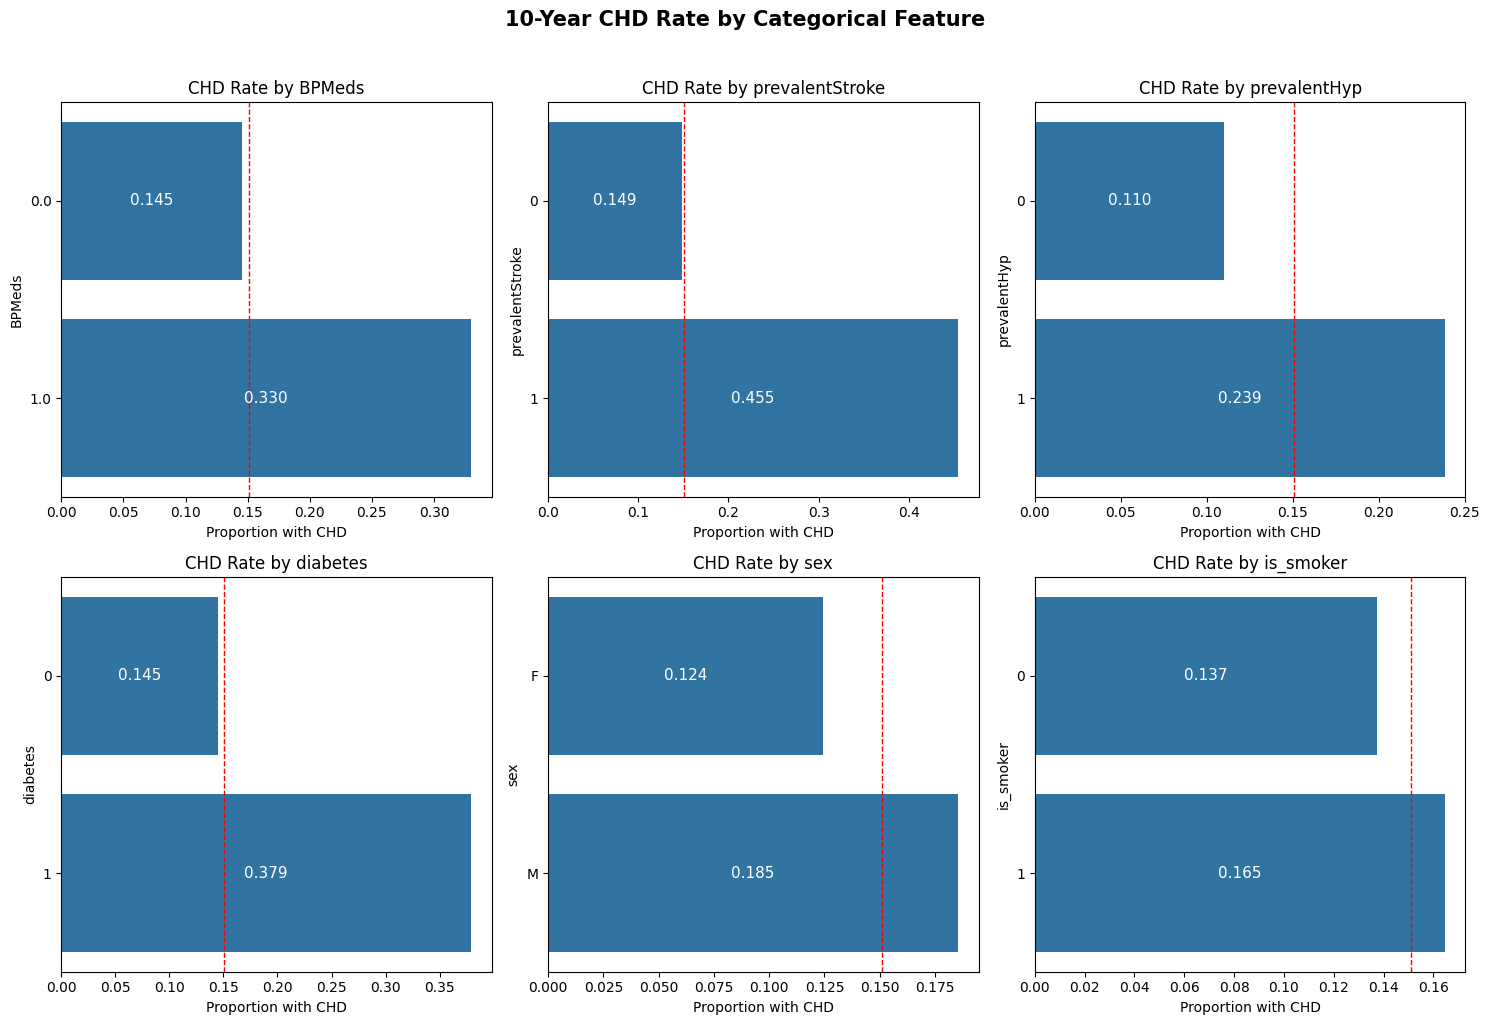

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ax = axes[i]
    chd_rate = cardio_cleaned.groupby(col)['TenYearCHD'].mean().reset_index()
    sns.barplot(
        data=chd_rate,
        x='TenYearCHD',
        y=col,
        ax=ax,
        orient='h'
    )

    # Annotate each bar
    for patch in ax.patches:
        width = patch.get_width()
        if width > 0:
            ax.text(
                width / 2,
                patch.get_y() + patch.get_height() / 2,
                f'{width:.3f}',
                va='center',
                ha='center',
                color='white',
                fontsize=11
            )

    axes[i].set_title(f'CHD Rate by {col}')
    axes[i].set_xlabel('Proportion with CHD')
    axes[i].set_ylabel(col)
    axes[i].axvline(x=0.151, color='red',
                    linestyle='--', linewidth=1)
    # red line shows overall CHD rate for reference

fig.suptitle('10-Year CHD Rate by Categorical Feature', fontsize=15, weight='bold', y=1.02)
fig.tight_layout()
plt.show()

**Categorical features — distribution and CHD association**

[Visualization 1 — count with CHD split]

[Visualization 2 — CHD rate by category]

The count charts in Visualization 1 give important context of sample size variation across features. For example, the positive cases of prevalentStroke, BPMeds, and diabetes have few observations, making their elevated CHD rates (Visualization 2) statistically weaker. PrevalentHyp and sex have sufficient counts to treat their CHD rate differences with more reliable signal strength.

CHD rate by category (red line = population average 15.1%):

| Feature | Group | CHD Rate | Reliable signal? |
|---------|-------|----------|-----------------|
| prevalentStroke | Prior stroke | ~45% | Caution — small n |
| BPMeds | On medication | ~32% | Caution — small n |
| diabetes | Diabetic | ~37% | Caution — small n |
| prevalentHyp | Hypertensive | ~23% | Yes |
| sex | Male | ~18% | Yes |
| is_smoker | Smoker | ~15% | Minimal difference |

> **Action:** prevalentHyp and sex are the strongest reliable categorical
> predictors. prevalentStroke, BPMeds, and diabetes show elevated CHD
> rates but small positive-class sample sizes — include in model but
> interpret coefficients with caution. is_smoker shows minimal
> differentiation as binary — evaluate cigsPerDay (continuous) as
> an alternative in variable selection.


### 2.3.1 Examining Potential Features (Ordinal- Education)

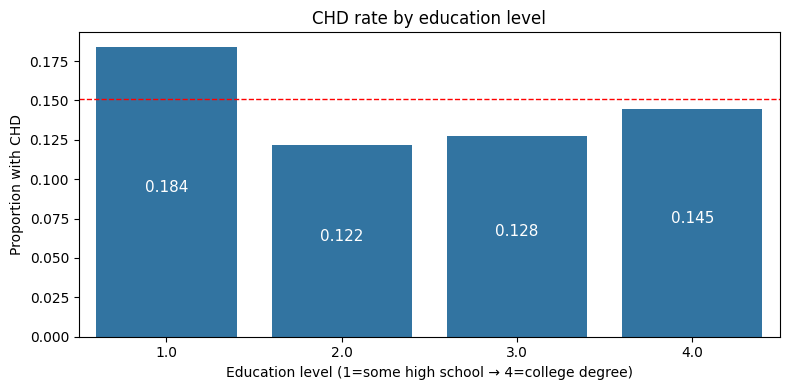

In [19]:
# plot the Education level (ordinal scale) vs CHD rates
fig, ax = plt.subplots(figsize=(8, 4))

chd_rate = cardio_cleaned.groupby('education')['TenYearCHD'].mean().reset_index()

sns.barplot(
    data=chd_rate,
    x='education',
    y='TenYearCHD',
    ax=ax
)

# Add value labels inside each bar
means = chd_rate['TenYearCHD'].values

for i in range(len(means)):
    ax.text(
        i,
        means[i]/2,
        str(round(means[i], 3)),
        fontdict=dict(color='white', fontsize=11),
        horizontalalignment='center'
    )

ax.axhline(y=0.151, color='red', linestyle='--', linewidth=1)
ax.set_title('CHD rate by education level')
ax.set_xlabel('Education level (1=some high school → 4=college degree)')
ax.set_ylabel('Proportion with CHD')
plt.tight_layout()
plt.show()

In [20]:
# assess the counts for Education levels to give context to CHD rates
print(cardio_cleaned['education'].value_counts().sort_index())
print(cardio_cleaned.groupby('education')['TenYearCHD'].agg(['mean','count']).round(3))

education
1.0    1391
2.0    1077
3.0     549
4.0     373
Name: count, dtype: int64
            mean  count
education              
1.0        0.184   1391
2.0        0.122   1077
3.0        0.128    549
4.0        0.145    373


**Education Level and CHD Rate**

| Level | Description | Count | CHD Rate |
|-------|-------------|-------|----------|
| 1.0 | Some high school | 1,391 | 18.4% |
| 2.0 | High school diploma | 1,077 | 12.2% |
| 3.0 | Some college | 549 | 12.8% |
| 4.0 | College degree | 373 | 14.5% |

Level 1 shows a meaningfully elevated CHD rate (18.4% vs 15.1%
population average) with the largest sample size. Given the size of the sample
in level 1, this finding is statistically robust.

Levels 2–4 sit between 12–14.5% with minimal differentiation.
The meaningful boundary is level 1 vs levels 2–4, not a linear
gradient across all four levels. This can reasonably be converted to a binary element.

> **Action:** education has marginal but real signal
> at level 1. Consider recoding as binary (level 1 = 1, levels 2–4
> = 0) before inclusion in the model — this better reflects the
> actual pattern in the data than treating it as a four-level
> ordinal variable, given the concentration of elevated CHD risk at the inital level.
> > **Action:** (below) recode education as binary `less_education`
> (1 = level 1, 0 = levels 2–4). CHD rate visualization
> confirms the split — low education group 18.4% vs 12.8%
> for higher education groups, both relative to 15.1% baseline.

In [21]:
# shift Education to a Binary category
cardio_cleaned['less_education'] = (cardio_cleaned['education'] == 1).astype(int)
print(cardio_cleaned['less_education'].dtype)
print(cardio_cleaned['less_education'].unique())
print(cardio_cleaned['less_education'].value_counts())

int64
[0 1]
less_education
0    1999
1    1391
Name: count, dtype: int64


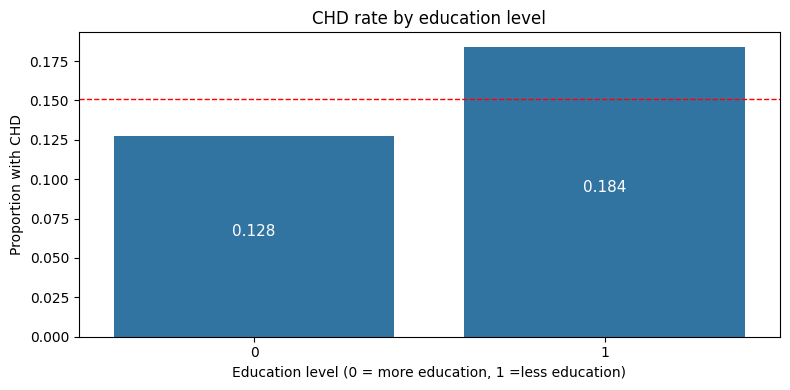

In [22]:
# visualize the Education vs. CHD rate with Binary configuration
fig, ax = plt.subplots(figsize=(8, 4))

chd_rate = cardio_cleaned.groupby('less_education')['TenYearCHD'].mean().reset_index()

sns.barplot(
    data=chd_rate,
    x='less_education',
    y='TenYearCHD',
    ax=ax
)

# Add value labels inside each bar
means = chd_rate['TenYearCHD'].values

for i in range(len(means)):
    ax.text(
        i,
        means[i]/2,
        str(round(means[i], 3)),
        fontdict=dict(color='white', fontsize=11),
        horizontalalignment='center'
    )

ax.axhline(y=0.151, color='red', linestyle='--', linewidth=1)
ax.set_title('CHD rate by education level')
ax.set_xlabel('Education level (0 = more education, 1 =less education)')
ax.set_ylabel('Proportion with CHD')
plt.tight_layout()
plt.show()


## 2.4 Numeric Feature Correlations and Box Comparisons with Ten Year CHD

**Visualization 1 — Correlation Matrix Heatmap**

What numeric features are correlated with TenYear CHD?
* *Example questions:* Are there strong, moderate, or weak predictors worth including in the model? Are there elements with little to no predictive value that may be dropped from the model?

**Visualization 2 — box plots by TenYearCHD group**

Do median and range comparisons clarify feature inclusion decisions beyond what correlation alone shows?

* *Example questions:* Do the box plots confirm or complicate the correlation findings? Are there columns with little to no discriminating difference between group despite being correlated?

> **Note:** the concluding markdown following these visualizations will be listed under 'Variable Selection' and
> combines categorical and numeric EDA findings into final feature
> recommendations for the logistic regression model.


Point-Biserial Correlations with TenYearCHD

Feature                r      p-value  Significant
--------------------------------------------------
age                0.225       0.0000          ***
cigsPerDay         0.068       0.0001          ***
totChol            0.092       0.0000          ***
sysBP              0.208       0.0000          ***
diaBP              0.136       0.0000          ***
BMI                0.066       0.0001          ***
heartRate          0.020       0.2404             
glucose            0.071       0.0000          ***


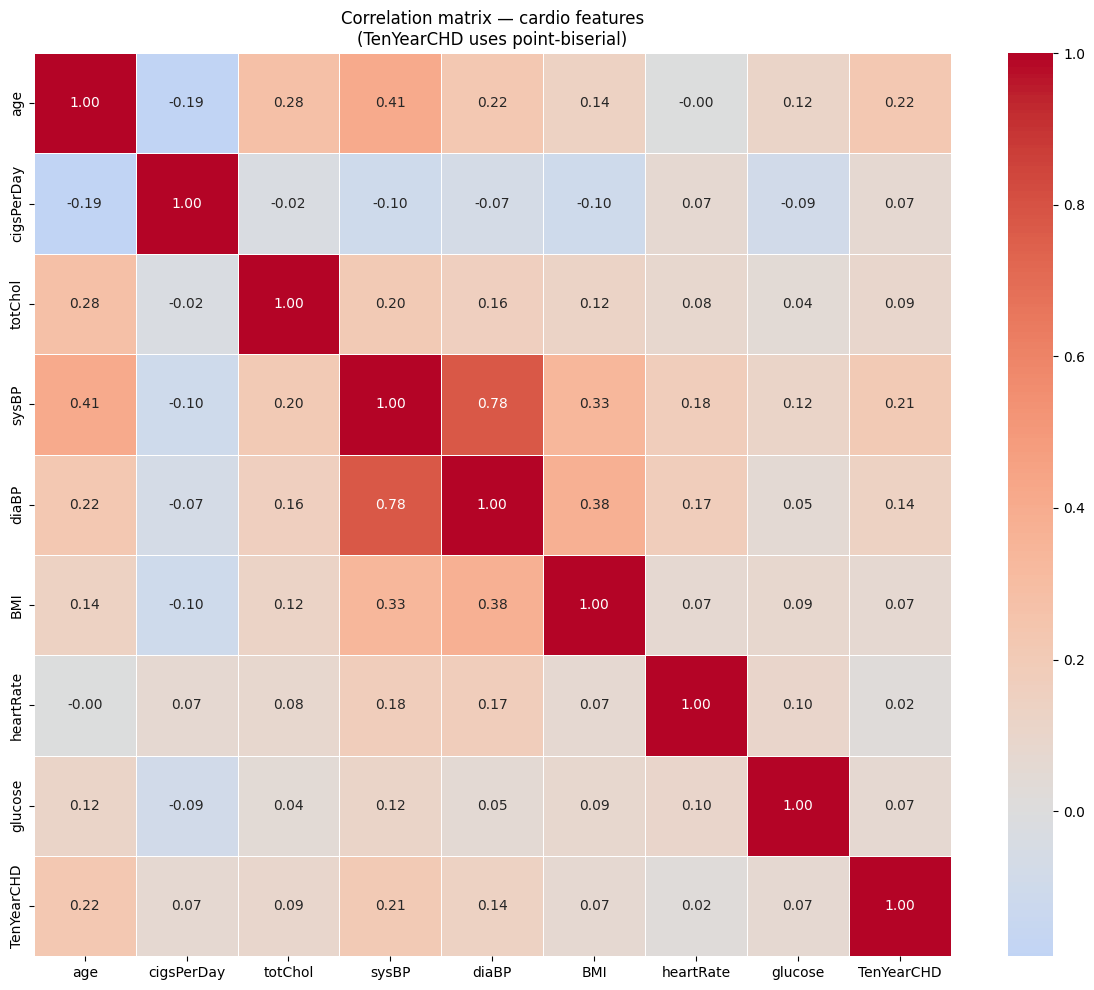

In [23]:
# print significance
binary_col = 'TenYearCHD'
continuous_cols = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']

print(f"Point-Biserial Correlations with {binary_col}\n")
print(f"{'Feature':<15} {'r':>8} {'p-value':>12} {'Significant':>12}")
print("-" * 50)

for col in continuous_cols:
    r, p = stats.pointbiserialr(cardio_cleaned[binary_col], cardio_cleaned[col])
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
    print(f"{col:<15} {r:>8.3f} {p:>12.4f} {sig:>12}")

# Visualize numeric data heatmap correlation
# Build the Pearson matrix without TenYearCHD first
corr_matrix = cardio_cleaned[continuous_cols].corr()

# Compute point-biserial for each continuous col vs TenYearCHD
pb_corrs = {}
for col in continuous_cols:
    r, p = stats.pointbiserialr(cardio_cleaned[binary_col], cardio_cleaned[col])
    pb_corrs[col] = r

# Insert as a row and column
import pandas as pd
pb_series = pd.Series(pb_corrs, name='TenYearCHD')
corr_matrix['TenYearCHD'] = pb_series
corr_matrix.loc['TenYearCHD'] = pb_series.tolist() + [1.0]

# Plot as before
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    linewidth=.5,
    cmap='coolwarm',
    center=0,
    ax=ax
)
ax.set_title('Correlation matrix — cardio features\n(TenYearCHD uses point-biserial)')
plt.tight_layout()
plt.show()



**Correlation heatmap — continuous features vs TenYearCHD**

Strongest continuous predictors of TenYearCHD:
- age (0.22) and sysBP (0.21) — modest but clear signal
- diaBP (0.14) — moderate, but note multicollinearity below
- totChol, glucose, cigsPerDay, BMI — weak (0.07–0.09)
- heartRate (0.02) — essentially no linear relationship with target

Notable multicollinearity: sysBP and diaBP correlated at 0.78 —
including both risks coefficient instability. Decision needed at
variable selection.

> **Action:** age and sysBP are primary continuous candidates.
> heartRate likely droppable. sysBP vs diaBP decision needed —
> sysBP preferred given stronger target correlation.

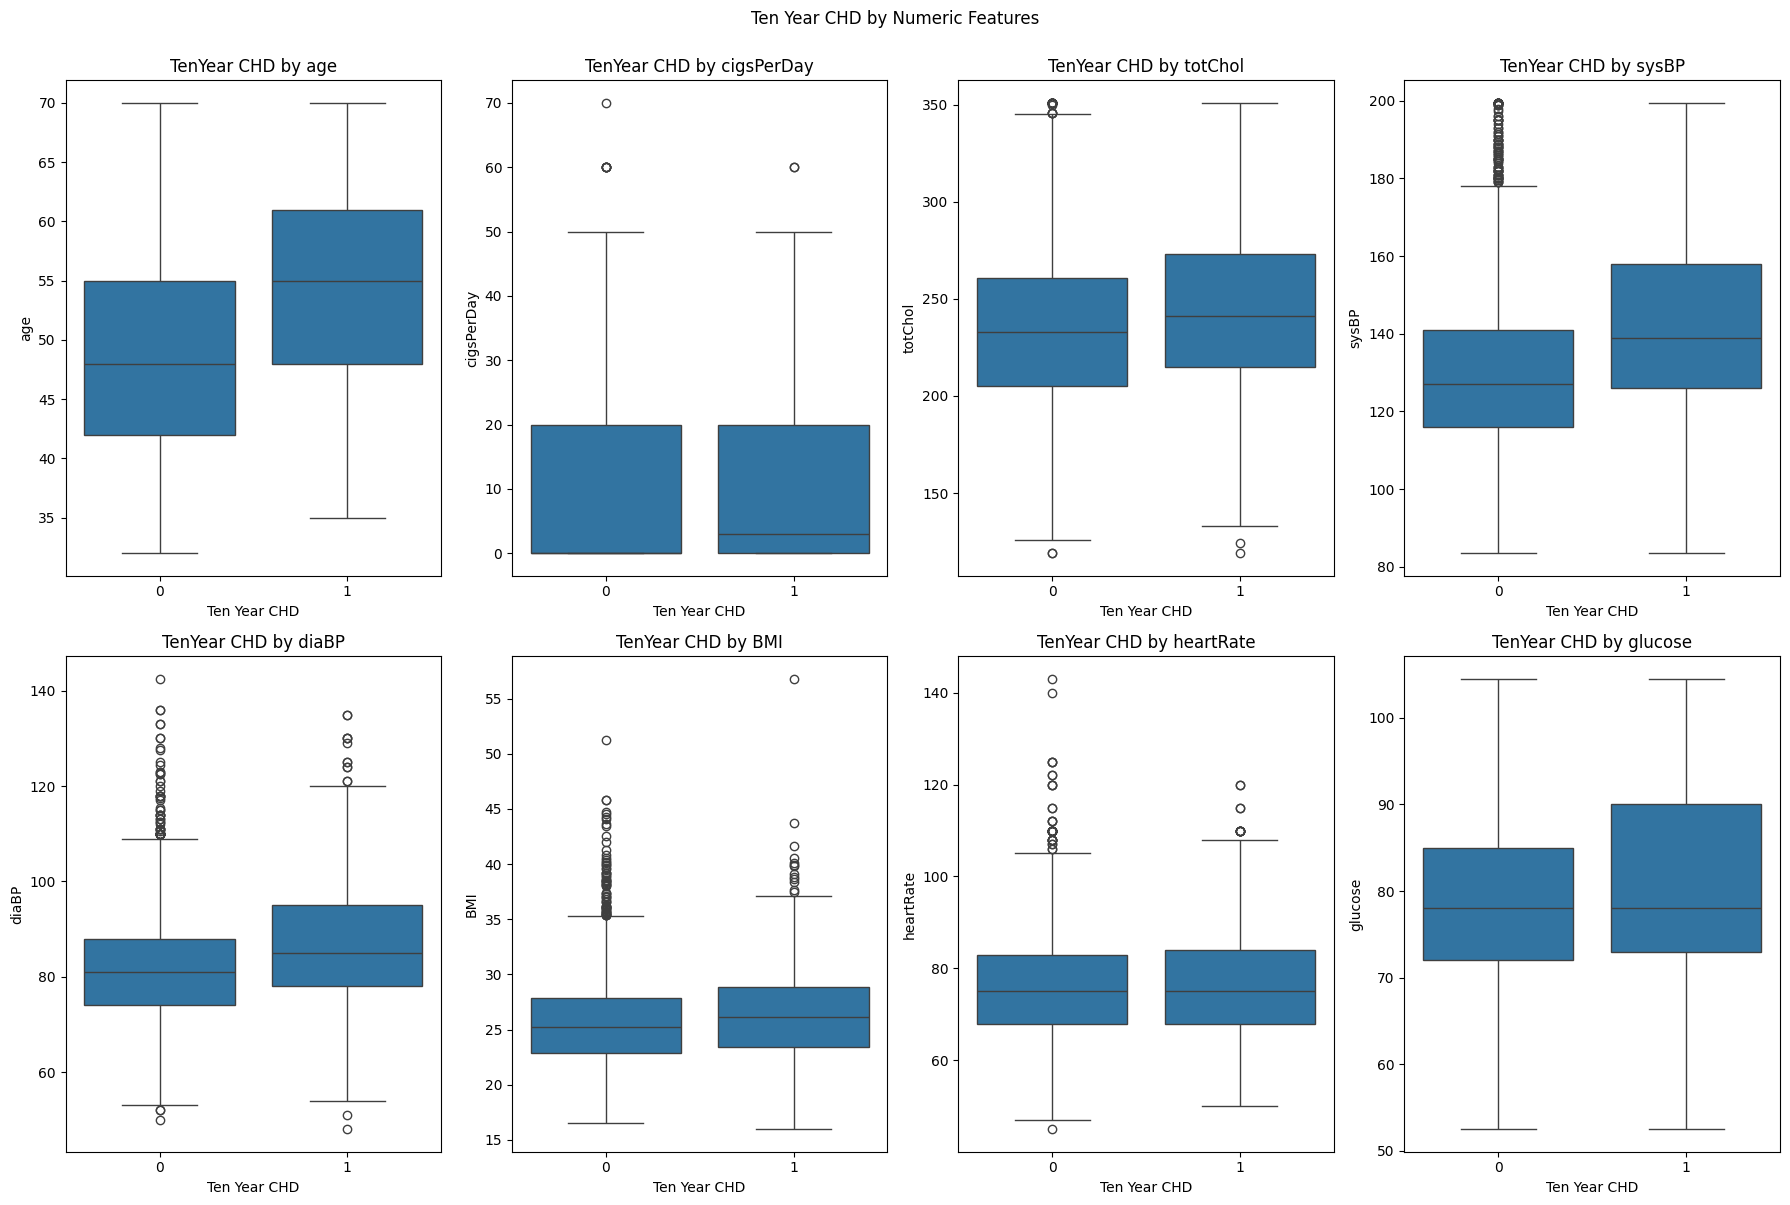

In [24]:
# visualize numeric columns using boxplots
numeric_cols = ['age', 'cigsPerDay', 'totChol', 'sysBP', 'diaBP', 'BMI',
                'heartRate', 'glucose']
fig, axes = plt.subplots(2,4, figsize=(18, 12))
axes = axes.flatten()


for i, col in enumerate(numeric_cols):
    sns.boxplot(
        data=cardio_cleaned,
        x= "TenYearCHD",          # which variable has the categories?
        y= col,          # which variable is the target?
        ax=axes[i],
    )
    axes[i].set_title(f'TenYear CHD by {col}')
    axes[i].set_xlabel('Ten Year CHD')
    axes[i].set_ylabel(col)
    axes[i].tick_params(axis='x')
    # think about which variables need rotated labels

fig.suptitle('Ten Year CHD by Numeric Features' , y=1)
fig.tight_layout()
plt.show()

## 2.5 Variable Selection

Based on EDA findings across correlation heatmap, box plots, categorical CHD rate charts, and education analysis.

**Target variable:** TenYearCHD (binary: 0 = no CHD, 1 = CHD)

***Selected continuous features***

| Feature | Correlation | Box plot separation | Decision |
|---------|-------------|--------------------| ---------|
| age | 0.22 | Strong — median ~6 yrs higher in CHD group | Keep as primary predictor |
| sysBP | 0.21 | Meaningful — CHD box clearly elevated | Keep as primary predictor |
| glucose | 0.07 | Weak overall — signal in upper tail | Keep — outlier pattern suggests tail signal beyond correlation |
| totChol | 0.09 | Minimal — boxes nearly identical | Borderline — include, monitor coefficient |
| BMI | 0.07 | Minimal — near complete overlap | Borderline — include, monitor coefficient |
| cigsPerDay | 0.07 | None — boxes identical | Borderline — continuous version adds little; however, keep and drop binary is_smoker |

***Selected categorical features***

| Feature | CHD rate signal | Decision |
|---------|----------------|----------|
| prevalentHyp | 23% vs 10% — reliable (large n) | Keep |
| sex | 18% male vs 12% female — reliable | Keep - encode (1=Male, 0=Female) before modeling |
| prevalentStroke | ~45% — elevated but small n | Keep — interpret coefficient cautiously |
| BPMeds | ~32% — elevated but small n | Keep — interpret coefficient cautiously |
| diabetes | ~37% — elevated but small n | Keep — interpret coefficient cautiously |
| less_education | 18.4% vs 12.8% — robust (n=1,391) | Keep — binary recoding captures non-linear pattern |

***Dropped features***

| Feature | Reason |
|---------|--------|
| heartRate | 0.02 correlation, no visual separation in box plot |
| diaBP | Collinear with sysBP (r=0.78) — sysBP retained as stronger predictor |
| id | Identifier — not a feature |
| education (original) | Replaced by low_education binary encoding |
| sex (object) | Needs encoding before modeling |
| is_smoker | ~15% — minimal differentiation |



# 3. Modeling

## 3.1 Model Preparation

###3.1.1 Build feature frame (deterministic transforms only)

In [25]:
# create modeling dataset from raw data — deterministic transforms only, no statistics computed yet
cardio_features = cardio_data.copy()

# encode sex
cardio_features['sex_male'] = (cardio_features['sex'] == 'M').astype(int)

# define feature columns — note: raw 'education' kept for now, 'less_education' derived after imputation
raw_feature_cols = ['age','prevalentHyp','sex_male','BPMeds','diabetes','education',
                     'sysBP','glucose','totChol','BMI','cigsPerDay','prevalentStroke']

X = cardio_features[raw_feature_cols]
y = cardio_features['TenYearCHD']

print(f'X shape: {X.shape}')
print(f'X nulls (expected — not yet imputed):\n{X.isnull().sum()[X.isnull().sum() > 0]}')

X shape: (3390, 12)
X nulls (expected — not yet imputed):
BPMeds         44
education      87
glucose       304
totChol        38
BMI            14
cigsPerDay     22
dtype: int64


###3.1.2 Train/validation/test split

In [26]:
# First split off the test set — held out untouched until final reporting
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Split remaining data into train and validation
# (0.25 of the remaining 80% = 20% of the total, giving a 60/20/20 split overall)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print(f'Training set size: {X_train.shape}')
print(f'Validation set size: {X_val.shape}')
print(f'Test set size: {X_test.shape}')

print('\nCHD distribution — train:', y_train.value_counts(normalize=True).round(3).to_dict())
print('CHD distribution — val:  ', y_val.value_counts(normalize=True).round(3).to_dict())
print('CHD distribution — test: ', y_test.value_counts(normalize=True).round(3).to_dict())

Training set size: (2034, 12)
Validation set size: (678, 12)
Test set size: (678, 12)

CHD distribution — train: {0: 0.849, 1: 0.151}
CHD distribution — val:   {0: 0.85, 1: 0.15}
CHD distribution — test:  {0: 0.85, 1: 0.15}


###3.1.3 Impute — fit medians on train, apply to both

In [27]:
impute_cols = ['glucose', 'education', 'BPMeds', 'totChol', 'cigsPerDay', 'BMI', 'heartRate']
impute_cols = [c for c in impute_cols if c in X_train.columns]

train_medians = X_train[impute_cols].median()

X_train[impute_cols] = X_train[impute_cols].fillna(train_medians)
X_val[impute_cols] = X_val[impute_cols].fillna(train_medians)
X_test[impute_cols] = X_test[impute_cols].fillna(train_medians)

print('Nulls remaining — train:', X_train[impute_cols].isnull().sum().sum())
print('Nulls remaining — val:  ', X_val[impute_cols].isnull().sum().sum())
print('Nulls remaining — test: ', X_test[impute_cols].isnull().sum().sum())

Nulls remaining — train: 0
Nulls remaining — val:   0
Nulls remaining — test:  0


###3.1.4 Derive less_education from the imputed column, then drop raw education

In [28]:
X_train['less_education'] = (X_train['education'] == 1).astype(int)
X_val['less_education'] = (X_val['education'] == 1).astype(int)
X_test['less_education'] = (X_test['education'] == 1).astype(int)

X_train = X_train.drop(columns='education')
X_val = X_val.drop(columns='education')
X_test = X_test.drop(columns='education')

###3.1.5 Winsorize — fit bounds on train, apply to both

In [29]:
def get_iqr_bounds(df, col):
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

def get_zscore_bounds(df, col, threshold=3):
    mean, std = df[col].mean(), df[col].std()
    return mean - threshold * std, mean + threshold * std

In [30]:
for col in ['totChol', 'glucose']:
    lower, upper = get_iqr_bounds(X_train, col)
    X_train[col] = X_train[col].clip(lower, upper)
    X_val[col] = X_val[col].clip(lower, upper)
    X_test[col] = X_test[col].clip(lower, upper)
    print(f'{col}: bounds=({lower:.1f}, {upper:.1f})')

lower, upper = get_zscore_bounds(X_train, 'sysBP')
X_train['sysBP'] = X_train['sysBP'].clip(lower, upper)
X_val['sysBP'] = X_val['sysBP'].clip(lower, upper)
X_test['sysBP'] = X_test['sysBP'].clip(lower, upper)
print(f'sysBP: bounds=({lower:.1f}, {upper:.1f})')

totChol: bounds=(118.0, 350.0)
glucose: bounds=(52.5, 104.5)
sysBP: bounds=(64.9, 200.2)


###3.1.6 Final validation

In [31]:
feature_cols = ['age','prevalentHyp','sex_male','BPMeds','diabetes','less_education',
                'sysBP','glucose','totChol','BMI','cigsPerDay','prevalentStroke']

print(f'X_train nulls: {X_train.isnull().sum().sum()}')
print(f'X_val nulls:   {X_val.isnull().sum().sum()}')
print(f'X_test nulls:  {X_test.isnull().sum().sum()}')

print(f'X_train shape: {X_train.shape}')
print(f'X_val shape:   {X_val.shape}')
print(f'X_test shape:  {X_test.shape}')

assert list(X_train.columns) == list(X_val.columns) == list(X_test.columns), \
    "Column mismatch between train, validation, and test"

X_train nulls: 0
X_val nulls:   0
X_test nulls:  0
X_train shape: (2034, 12)
X_val shape:   (678, 12)
X_test shape:  (678, 12)


## 3.2 Logistic Regression

### 3.2.1 Fit Model

In [32]:
# fit model — class_weight='balanced' compensates for 85/15 imbalance
model = LogisticRegression(
    random_state = 42,
    class_weight = 'balanced',
    max_iter = 2000
)
model.fit(X_train, y_train)

# generate predicted probabilities — needed for ROC curve
# predict_proba returns [prob_class_0, prob_class_1]
# [:,1] selects probability of CHD=1
y_prob_train = model.predict_proba(X_train)[:, 1]
y_prob_val = model.predict_proba(X_val)[:, 1]      # new — used for threshold selection
y_prob_test = model.predict_proba(X_test)[:, 1]    # untouched — final reporting only

# default threshold predictions (0.5) for baseline comparison
y_pred_default = model.predict(X_test)

print('Model fitted successfully')
print(f'Training samples: {X_train.shape[0]}')
print(f'Validation samples: {X_val.shape[0]}')
print(f'Test samples: {X_test.shape[0]}')

Model fitted successfully
Training samples: 2034
Validation samples: 678
Test samples: 678


## 3.3 Metric Selection and Threshold Optimization

### 3.3.1 Argument for ROC-AUC and recall over accuracy

**Why not accuracy**

This dataset has a class imbalance at 85/15. A classifier that predicts no CHD would have ~85% accuracy by default with no clinical value. Therefore, accuracy would be a misleading metric for this problem.

**Why ROC-AUC**

ROC-AUC measures the model's ability to discriminate between CHD and no-CHD patients across all possible thresholds. It is not affected by
class imbalance because it does not depend on a fixed cutoff, but test all possibilities across all the possible thresholds.

An area under the curve (AUC) of 0.5 means the model performs no better than random chance. An AUC of 1.0 mean would indicate perfect discrimination. The AUC represents the probability that a randomly selected CHD patient receives a higher risk score than a randomly selected non-CHD patient.

**Why recall matters for threshold selection**

In clinical CHD screening, avoiding false negatives (missed CHD cases) are more important than avoiding false positives (unnecessary follow-up). The former would have implications for mortality and health outcomes. The implications of the latter are being inconvenienced (but not harmed) by additional testing.

This clinical asymmetry justifies lowering the classification threshold below 0.5 to improve recall, accepting more false positives in exchange for catching more true CHD cases.

### 3.3.2 ROC curve (validation set) — for threshold selection

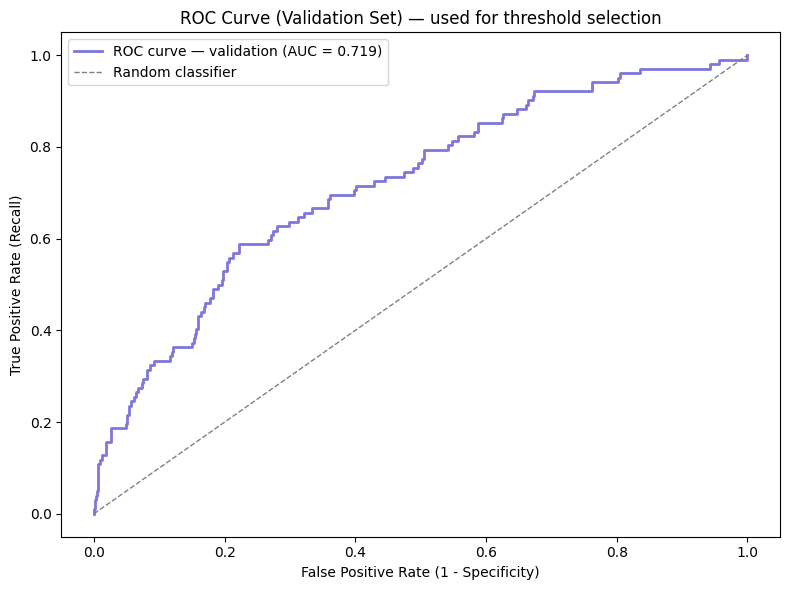

In [33]:
from sklearn.metrics import roc_curve, roc_auc_score

# Threshold selection happens on the validation set — test set stays untouched until 3.3.4/3.4
fpr, tpr, thresholds = roc_curve(y_val, y_prob_val)
auc_val = roc_auc_score(y_val, y_prob_val)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='#7F77DD', linewidth=2, label=f'ROC curve — validation (AUC = {auc_val:.3f})')
ax.plot([0,1], [0,1], color='gray', linestyle='--', linewidth=1, label='Random classifier')
ax.set_xlabel('False Positive Rate (1 - Specificity)')
ax.set_ylabel('True Positive Rate (Recall)')
ax.set_title('ROC Curve (Validation Set) — used for threshold selection')
ax.legend()
plt.tight_layout()
plt.show()

### 3.3.3 Optimal threshold calculation

In [34]:
from sklearn.metrics import recall_score, precision_score

# --- Youden's J (equal weight to sensitivity and specificity) ---
j_scores = tpr - fpr
optimal_idx_j = j_scores.argmax()
optimal_threshold_j = thresholds[optimal_idx_j]

print("=== Youden's J-optimal threshold ===")
print(f'Threshold: {optimal_threshold_j:.3f}')
print(f'  Recall: {tpr[optimal_idx_j]:.3f}')
print(f'  Specificity: {1 - fpr[optimal_idx_j]:.3f}')

# --- Constrained search: among thresholds achieving recall >= min_recall on
# validation, pick the one with the best precision (i.e., fewest wasted
# follow-ups). Rationale: a missed CHD case (false negative) carries
# mortality risk, while a false positive only leads to additional
# screening — so we require a minimum recall the model must meet, then
# optimize precision subject to that constraint, rather than letting an
# unconstrained formula (like F2) find a mathematically optimal but
# clinically impractical operating point.
min_recall = 0.75

candidate_thresholds = np.linspace(0.01, 0.99, 199)
results = []
for t in candidate_thresholds:
    preds = (y_prob_val >= t).astype(int)
    r = recall_score(y_val, preds)
    p = precision_score(y_val, preds, zero_division=0)
    if r >= min_recall:
        results.append((t, r, p))

optimal_threshold_constrained = max(results, key=lambda x: x[2])[0]
y_pred_val_constrained = (y_prob_val >= optimal_threshold_constrained).astype(int)

print(f'\nThreshold (recall >= {min_recall}): {optimal_threshold_constrained:.3f}')
print(f'  Recall: {recall_score(y_val, y_pred_val_constrained):.3f}')
print(f'  Precision: {precision_score(y_val, y_pred_val_constrained):.3f}')

=== Youden's J-optimal threshold ===
Threshold: 0.581
  Recall: 0.588
  Specificity: 0.778

Threshold (recall >= 0.75): 0.401
  Recall: 0.794
  Precision: 0.218


### 3.3.4 Compare default vs optimal threshold

In [35]:
### 3.3.4 Compare default vs optimal threshold

from sklearn.metrics import (classification_report,
                              confusion_matrix,
                              accuracy_score)

y_pred_default = model.predict(X_test)
y_pred_j = (y_prob_test >= optimal_threshold_j).astype(int)
y_pred_constrained = (y_prob_test >= optimal_threshold_constrained).astype(int)

print('=== DEFAULT THRESHOLD (0.5) ===')
print(classification_report(y_test, y_pred_default))

print(f'=== YOUDEN\'S J THRESHOLD ({optimal_threshold_j:.3f}) ===')
print(classification_report(y_test, y_pred_j))

print(f'=== CONSTRAINED THRESHOLD, recall >= {min_recall} ({optimal_threshold_constrained:.3f}) ===')
print(classification_report(y_test, y_pred_constrained))

=== DEFAULT THRESHOLD (0.5) ===
              precision    recall  f1-score   support

           0       0.92      0.73      0.82       576
           1       0.30      0.65      0.41       102

    accuracy                           0.72       678
   macro avg       0.61      0.69      0.61       678
weighted avg       0.83      0.72      0.75       678

=== YOUDEN'S J THRESHOLD (0.581) ===
              precision    recall  f1-score   support

           0       0.90      0.83      0.86       576
           1       0.33      0.47      0.39       102

    accuracy                           0.78       678
   macro avg       0.61      0.65      0.63       678
weighted avg       0.81      0.78      0.79       678

=== CONSTRAINED THRESHOLD, recall >= 0.75 (0.401) ===
              precision    recall  f1-score   support

           0       0.93      0.54      0.69       576
           1       0.23      0.77      0.36       102

    accuracy                           0.58       678
   ma

## 3.4 Model Metrics

In [36]:
final_test_auc = roc_auc_score(y_test, y_prob_test)
print(f'Final test-set ROC-AUC: {final_test_auc:.3f}')

Final test-set ROC-AUC: 0.713


**Final test-set ROC-AUC: 0.713**
The model correctly ranks a randomly selected CHD patient above
a randomly selected non-CHD patient 71.3% of the time —
substantially better than random chance (0.5), and computed once
on the held-out test set after all preprocessing and threshold
decisions were finalized on training/validation data only.

**Threshold selection: choosing recall over an unweighted criterion**
Youden's J statistic — which weights sensitivity and specificity
equally — selects a threshold of 0.581, but this *reduces* recall
relative to the default 0.5 (47% vs 65%). Given the clinical
asymmetry in this problem — a missed CHD case carries mortality
risk, while a false positive leads only to additional screening —
an unweighted criterion is not appropriate here. We instead search
for the threshold that maximizes precision subject to a minimum
recall of 75%, chosen to reflect a clinical priority on catching
true CHD cases over avoiding false alarms.

| Metric | Default (0.50) | Youden's J (0.581) | Recall-constrained (0.401) |
|--------|-----------------|---------------------|------------------------------|
| Accuracy | 72% | 78% | 58% |
| Recall — CHD | 65% | 47% | 77% |
| Precision — CHD | 30% | 33% | 23% |
| F1 — CHD | 0.41 | 0.39 | 0.36 |

**Key finding:** the recall-constrained threshold (0.401) catches
77% of true CHD cases — 12 percentage points more than the default
threshold, and 30 points more than Youden's J — at the cost of a
substantially lower precision (23%) and overall accuracy (58%).
Concretely, roughly half of all patients screened at this threshold
are flagged for follow-up, of whom fewer than one in four actually
have CHD. We consider this an acceptable tradeoff given that the
cost of a missed case is materially higher than the cost of an
unnecessary follow-up test, but this threshold should not be
interpreted as a general-purpose operating point — it reflects a
deliberate choice to prioritize sensitivity for this specific
clinical use case.

**Note on accuracy:** a naive all-zeros classifier achieves 84.9%
accuracy simply by predicting "no CHD" for everyone, higher than
any of the three thresholds above. This confirms accuracy is a
misleading metric for this imbalanced dataset, and that recall and
precision — not accuracy — are the metrics that should drive
threshold selection here.

## 3.5 Coefficient Interpretation and Predictive Power

In [37]:
# build coefficient table
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_[0]  # [0] needed because logistic regression
                                    # returns 2D array even for binary classification
}).sort_values('Coefficient', ascending=False).reset_index(drop=True)

# convert log-odds to odds ratios
# this is the key difference from Melbourne
coef_df['Odds Ratio'] = np.exp(coef_df['Coefficient']).round(3)

print(coef_df.to_string())
print(f'\nIntercept: {model.intercept_[0]:.3f}')

            Feature  Coefficient  Odds Ratio
0   prevalentStroke     0.670958       1.956
1          diabetes     0.560324       1.751
2          sex_male     0.502498       1.653
3      prevalentHyp     0.279306       1.322
4               age     0.055571       1.057
5    less_education     0.025177       1.025
6        cigsPerDay     0.024355       1.025
7             sysBP     0.018784       1.019
8           totChol     0.002319       1.002
9           glucose     0.000998       1.001
10              BMI    -0.023386       0.977
11           BPMeds    -0.050816       0.950

Intercept: -6.098


**Coefficient Interpretation and Predictive Power**

Coefficients converted to odds ratios using e^coefficient.
Odds ratio >1 = increased CHD odds; <1 = decreased CHD odds.
Reference categories: female (sex_male=0), no hypertension,
no diabetes, no prior stroke, not on BP medication.

| Feature | Coefficient | Odds Ratio | Interpretation |
|---------|-------------|------------|----------------|
| prevalentStroke | 0.671 | 1.956 | Prior stroke nearly doubles CHD odds — strongest predictor |
| diabetes | 0.560 | 1.751 | Diabetes multiplies CHD odds by 1.75x — second strongest |
| sex_male | 0.502 | 1.653 | Males have 1.65x higher CHD odds than females |
| prevalentHyp | 0.279 | 1.322 | Hypertension increases CHD odds by 32% |
| age | 0.056 | 1.057 | Each additional year increases CHD odds by ~6% |
| less_education | 0.025 | 1.025 | Minimal independent contribution |
| cigsPerDay | 0.024 | 1.025 | Minimal independent contribution |
| sysBP | 0.019 | 1.019 | Near-zero after controlling for hypertension variables |
| totChol | 0.002 | 1.002 | No meaningful contribution |
| glucose | 0.001 | 1.001 | No meaningful contribution |
| BMI | -0.023 | 0.977 | No meaningful contribution |
| BPMeds | -0.051 | 0.950 | Slightly *lower* odds — likely reflects effective BP control among treated patients, not a protective effect of the medication itself |

# 4. Key Findings and Summary

## 4.1 Key Findings

**Prior stroke is the strongest predictor, ahead of diabetes.**
PrevalentStroke (OR=1.956) narrowly outranks diabetes (OR=1.751)
as the single strongest predictor in the model. Prior stroke and
CHD share the same underlying atherosclerotic disease process — a
patient who has had a stroke has already demonstrated pre-existing
cardiovascular illness, which the model picks up on despite the
smaller sample size flagged for this variable during EDA.

**Binary clinical flags dominate over continuous measurements.**
The four strongest predictors are all categorical (prevalentStroke,
diabetes, sex, hypertension). Together they carry far more
predictive power than any continuous measurement, including age
and sysBP.

**BPMeds shows a small negative association, not a positive one.**
Unlike the earlier (leaky) version of this model, the corrected
pipeline shows patients on blood pressure medication have very
slightly *lower* odds of CHD (OR=0.950) after controlling for
hypertension status. This is more plausibly explained by effective
treatment — medicated patients have their blood pressure actively
managed — than by BP medication itself being protective. The effect
size is small enough that we don't read strong signal into it either
way.

**SysBP multicollinearity confirmed (OR=1.019).**
Despite ranking second in bivariate correlation during EDA, sysBP
contributes minimally in the multivariate model — prevalentHyp and
BPMeds absorb most of the blood pressure signal independently.

**Age compounds meaningfully.**
A ~6% odds increase per year means a 65-year-old has approximately
3.0x higher CHD odds than a 45-year-old, holding all else constant
— for comparison, that's a larger swing in odds than having
diabetes on its own.

**Continuous features confirmed as weak predictors.**
BMI, glucose, totChol, and cigsPerDay (retained as borderline
inclusions based on clinical relevance) show near-zero or
negligible odds ratios in the multivariate model. Their inclusion
did not materially improve model performance.


## 4.2 Model Summary

| Metric | Value |
|--------|-------|
| ROC-AUC (test set) | 0.713 |
| Selected threshold | 0.401 (recall-constrained, min. recall 75%) |
| Recall at selected threshold | 77% |
| Precision at selected threshold | 23% |
| Accuracy at selected threshold | 58% |
| Youden's J threshold (for comparison) | 0.581 — recall 47%, precision 33% |
| Baseline accuracy (naive classifier) | 84.9% |

The model achieves a ROC-AUC of 0.713, indicating meaningful
discriminating ability well above random chance. Rather than
selecting a threshold that treats sensitivity and specificity as
equally important, we chose a threshold that guarantees at least
75% recall on validation data, prioritizing the detection of true
CHD cases in line with the clinical cost of a missed diagnosis.
At this threshold, the model correctly identifies 77% of patients
who will develop CHD within 10 years, at the cost of a high false
positive rate that would require this model to be paired with
appropriately scaled follow-up screening capacity in any real
deployment.